# 02 — Feature Engineering & Model Development

**Heart Disease Risk Classifier · BITS Pilani AIMLCZG523 · Assignment 01**

This notebook mirrors `src/train.py`. It:

1. Loads the cleaned dataset produced by `src/data_processing.py`.
2. Builds a `ColumnTransformer` (scaling + one-hot encoding).
3. Trains and tunes **three** models — Logistic Regression, Random Forest,
   and XGBoost — each as a full sklearn `Pipeline`.
4. Compares them on the held-out test set and selects a winner by ROC-AUC.

> Every model is wrapped in a `Pipeline(preprocessor + estimator)` so the saved
> artifact is self-contained and reusable at inference time.

## 1 — Setup

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Resolve project root regardless of launch directory.
_here = Path().resolve()
PROJECT_ROOT = _here.parent if _here.name == 'notebooks' else _here
os.chdir(PROJECT_ROOT)

plt.style.use('seaborn-v0_8-whitegrid')
print('Project root:', PROJECT_ROOT)

Project root: C:\gmr\projects\mtech_mlops_assignment_01


In [2]:
from src.data_processing import NUMERIC_COLS, CATEGORICAL_COLS, TARGET_COL, build_preprocessor
from src.train import build_search_spaces, evaluate

FEATURE_COLS = NUMERIC_COLS + CATEGORICAL_COLS
print('Numeric    :', NUMERIC_COLS)
print('Categorical:', CATEGORICAL_COLS)
print('Target     :', TARGET_COL)

Numeric    : ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Target     : num


## 2 — Load Processed Data

In [3]:
df = pd.read_csv('data/processed/heart_disease_clean.csv')
X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].astype(int)
print('Feature matrix:', X.shape)
print('Class balance :', dict(y.value_counts().sort_index()))
X.head()

Feature matrix: (303, 13)
Class balance : {0: 164, 1: 139}


,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang,slope,ca,thal
0,63,145,233,150,2.3,1,1,1,2,0,3,0.0,6.0
1,67,160,286,108,1.5,1,4,0,2,1,2,3.0,3.0
2,67,120,229,129,2.6,1,4,0,2,1,2,2.0,7.0
3,37,130,250,187,3.5,1,3,0,0,0,3,0.0,3.0
4,41,130,204,172,1.4,0,2,0,2,0,1,0.0,3.0


## 3 — Train/Test Split (stratified 80/20)

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print('Train:', X_train.shape[0], ' Test:', X_test.shape[0])

Train: 242  Test: 61


## 4 — Preprocessing Pipeline

In [5]:
preprocessor = build_preprocessor(X)
preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['age', 'trestbps', 'chol', 'thalach',
                                  'oldpeak']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['sex', 'cp', 'fbs', 'restecg', 'exang',
                                  'slope', 'ca', 'thal'])])

## 5 — Train & Tune Three Models

Logistic Regression (GridSearchCV), Random Forest and XGBoost (RandomizedSearchCV), each a full `Pipeline`.

In [6]:
searches = build_search_spaces(preprocessor)

fitted = {}
best_params_all = {}
results = {}

for name, (search, _, tuner) in searches.items():
    print(f'Tuning {name} via {tuner} ...')
    search.fit(X_train, y_train)
    fitted[name] = search.best_estimator_
    best_params_all[name] = {k.replace('model__', ''): v for k, v in search.best_params_.items()}
    results[name] = evaluate(fitted[name], X_train, y_train, X_test, y_test)
    print(f'   best params : {best_params_all[name]}')
    print(f'   test ROC-AUC: {results[name]["roc_auc"]}')

Tuning LogisticRegression via GridSearchCV ...


   best params : {'C': 1.0, 'penalty': 'l1', 'solver': 'liblinear'}
   test ROC-AUC: 0.9589
Tuning RandomForest via RandomizedSearchCV ...


   best params : {'n_estimators': 500, 'min_samples_split': 5, 'max_depth': 6}
   test ROC-AUC: 0.9481
Tuning XGBoost via RandomizedSearchCV ...


   best params : {'subsample': 0.6, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.01}
   test ROC-AUC: 0.9437


## 6 — Model Comparison

In [7]:
comparison = pd.DataFrame(results).T[
    ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'cv_mean', 'cv_std']
].round(4)
comparison

,accuracy,precision,recall,f1_score,roc_auc,cv_mean,cv_std
LogisticRegression,0.8689,0.8333,0.8929,0.8621,0.9589,0.9070,0.0114
RandomForest,0.8689,0.8333,0.8929,0.8621,0.9481,0.9017,0.0271
XGBoost,0.8852,0.8621,0.8929,0.8772,0.9437,0.8846,0.0271


## 7 — ROC Curves

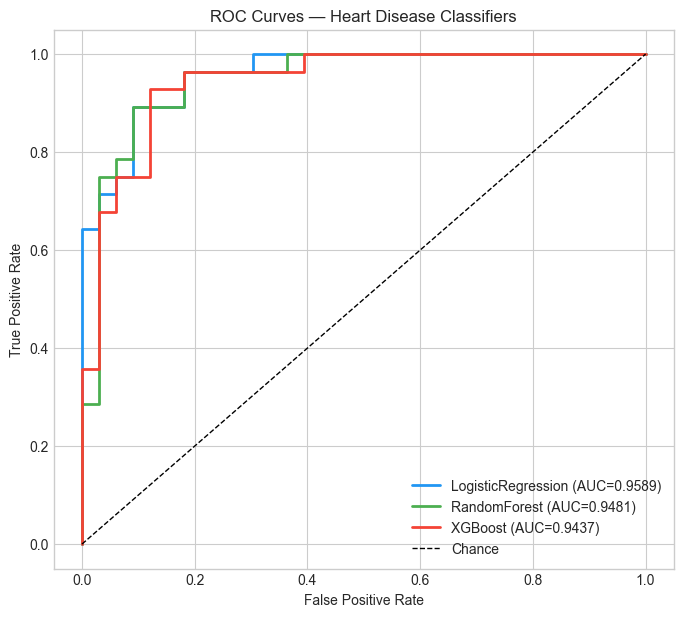

In [8]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(8, 7))
palette = {'LogisticRegression': '#2196F3', 'RandomForest': '#4CAF50', 'XGBoost': '#F44336'}
for name, pipe in fitted.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, proba):.4f})',
            color=palette[name], lw=2)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Heart Disease Classifiers'); ax.legend(loc='lower right')
plt.show()

## 8 — Confusion Matrices

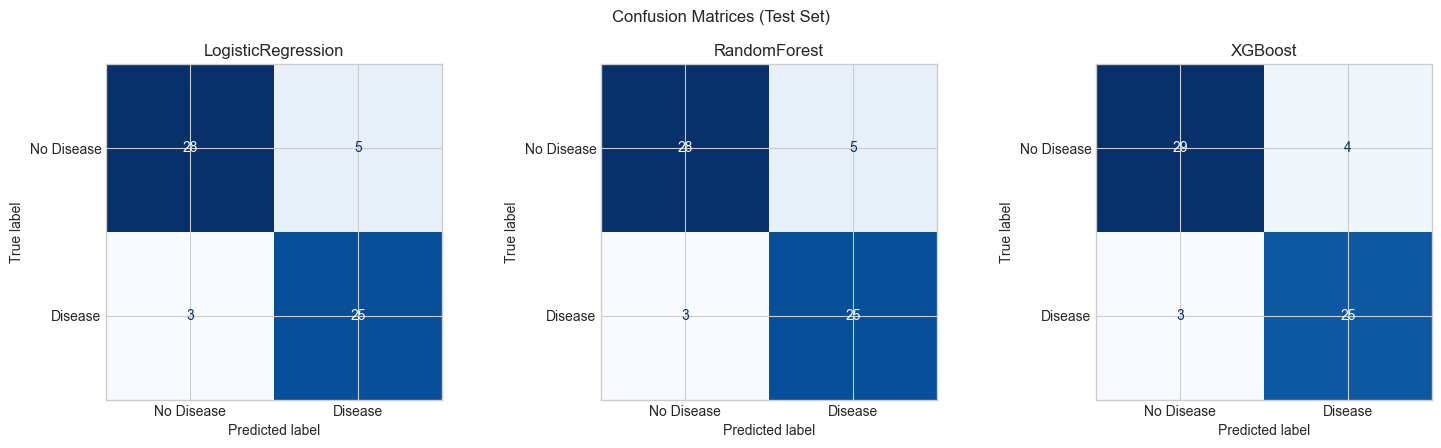

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, pipe) in zip(axes, fitted.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Disease']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
fig.suptitle('Confusion Matrices (Test Set)'); plt.tight_layout(); plt.show()

## 9 — Feature Importances

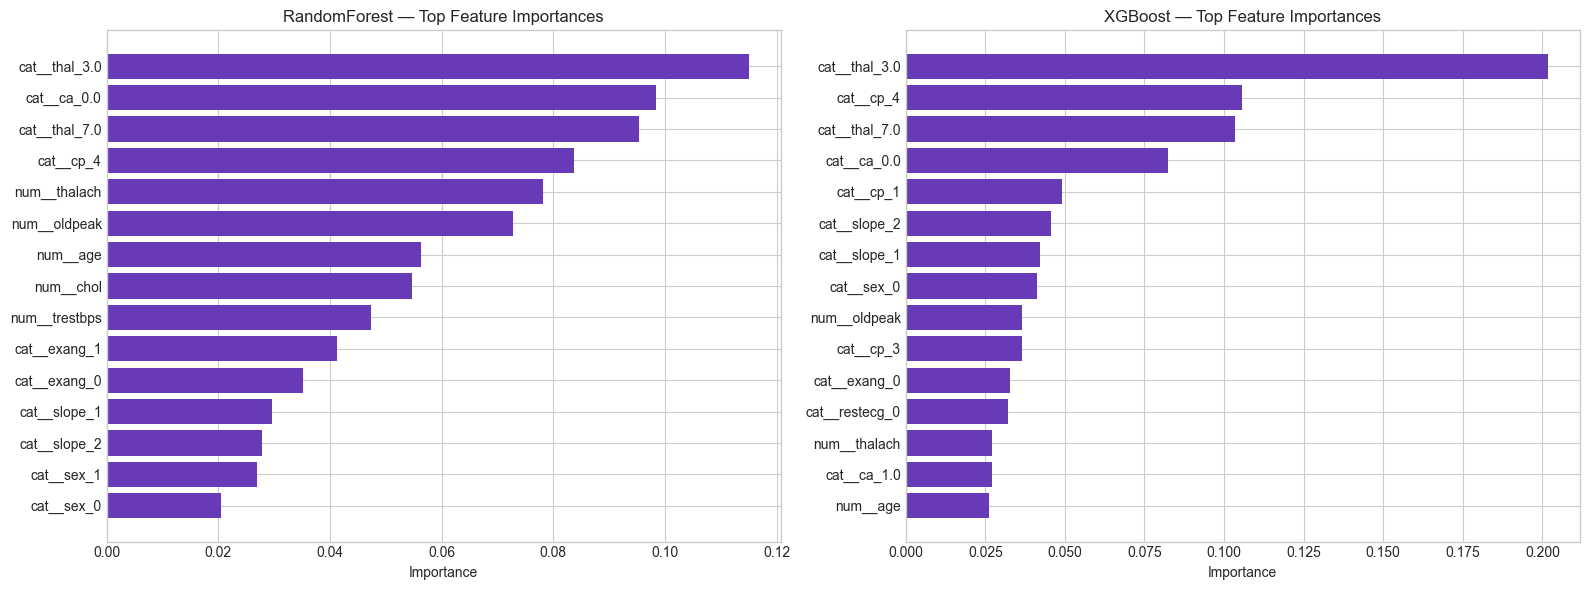

In [10]:
tree_models = [n for n in ('RandomForest', 'XGBoost') if n in fitted]
fig, axes = plt.subplots(1, len(tree_models), figsize=(8 * len(tree_models), 6))
axes = np.atleast_1d(axes)
for ax, name in zip(axes, tree_models):
    pipe = fitted[name]
    feat_names = pipe.named_steps['preprocessor'].get_feature_names_out()
    importances = pipe.named_steps['model'].feature_importances_
    order = np.argsort(importances)[::-1][:15]
    ax.barh([feat_names[i] for i in order][::-1], importances[order][::-1], color='#673AB7')
    ax.set_title(f'{name} — Top Feature Importances'); ax.set_xlabel('Importance')
plt.tight_layout(); plt.show()

## 10 — Winner

In [11]:
best_name = max(results, key=lambda n: results[n]['roc_auc'])
print('Winner:', best_name, '(ROC-AUC =', results[best_name]['roc_auc'], ')')
print('Best params:', best_params_all[best_name])

Winner: LogisticRegression (ROC-AUC = 0.9589 )
Best params: {'C': 1.0, 'penalty': 'l1', 'solver': 'liblinear'}


## Model Selection Justification

The winning model is chosen by **test-set ROC-AUC**, which is the most
appropriate headline metric here because:

- **Clinical framing** — this is a screening task; ranking patients by risk
  (which ROC-AUC measures) matters more than accuracy at a single threshold.
- **Threshold independence** — ROC-AUC summarises performance across all
  decision thresholds, so the choice is robust to where we later set the
  0.5 cutoff.
- **Class balance** — the dataset is only mildly imbalanced, and ROC-AUC is
  read alongside precision/recall/F1 in the comparison table above to confirm
  the winner is not trading recall for precision (or vice-versa).

The winner's 5-fold cross-validated ROC-AUC (`cv_mean ± cv_std`) is reported
next to its test score to confirm the result generalises and is not an artifact
of the particular train/test split. The full fitted pipeline (preprocessor +
estimator) for this model is what `src/train.py` serializes to
`models/best_model_pipeline.pkl`.